In [4]:
from transformers import AutoProcessor, AutoModelForMultimodalLM
from PIL import Image

In [2]:
# !pip install "transformers[serving] @ git+https://github.com/huggingface/transformers.git@main"

In [3]:
processor = AutoProcessor.from_pretrained("Qwen/Qwen3.5-35B-A3B")
model = AutoModelForMultimodalLM.from_pretrained("Qwen/Qwen3.5-35B-A3B")

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/1026 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

In [5]:
with open("/mnt/DATA2/varlamova/HTR/trocr/data/texts/hwr200/filtered_lines_v2/lines_txt/48_reuse4_Сканы_1_0025.txt", "r", encoding="utf-8") as f:
    target = f.read()

image = Image.open("/mnt/DATA2/varlamova/HTR/trocr/data/texts/hwr200/filtered_lines_v2/lines/48_reuse4_Сканы_1_0025.png")

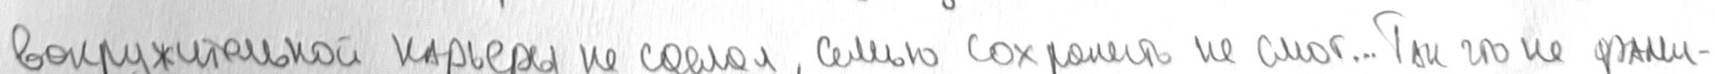

In [8]:
image

In [9]:
target

'головокружительной карьеры не сделал, семью сохранить не смог... Так что не-'

In [11]:
prompt = "Recognize a line of handwritten Russian text"

In [6]:
prompt = f"""
You are given:
1. An image containing handwritten Russian text.
2. OCR text extracted from that image.

Target OCR text:
{target}

Task:
Correct the OCR text by comparing it with the handwritten text in the image.

Rules:
- Use the image as the source of truth.
- Fix only clear OCR recognition errors.
- Preserve wording, formatting, punctuation, and line breaks.
- Do not rewrite, paraphrase, or improve the text.
- If uncertain, keep the original OCR text.
- Output only the corrected text.
"""

In [12]:
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": prompt}
        ]
    },
]
inputs = processor.apply_chat_template(
	messages,
	add_generation_prompt=True,
	tokenize=True,
	return_dict=True,
	return_tensors="pt",
).to(model.device)

outputs = model.generate(**inputs, max_new_tokens=300)
print(processor.decode(outputs[0][inputs["input_ids"].shape[-1]:]))

Based on the visual content of the image, I see a line of handwritten Cyrillic text. I will scan the characters from left to right to transcribe them.

1.  The first word looks like "вокругильной" or "вожжательной". Looking closer at the cursive loops, it seems to start with "в", then "о", "к", "р", "у", "ж", "и", "т", "е", "л", "ь", "н", "о", "й". So, "вожжательной" (or similar variation like "вокругильной" but "вожжательной" makes more sense in context if it were "водительной" - wait, let me re-examine).
    *   Actually, looking very closely at the start: "в", "о", "к", "р", "у", "ж", "и", "т", "е", "л", "ь", "н", "о", "й". It looks like "вокругильной". No, that's not a common word.
    *   Let's look at the next word. "карьеры". That is clear. "карьеры".
    *   So the phrase starts with "вокругильной карьеры". This doesn't make much sense.
    *   Let's reconsider the first word. Maybe "вож
